In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

print("Experiment notebook hazır.")

Experiment notebook hazır.


In [2]:
df = pd.read_csv("../data/amzn_stock.csv", index_col="Date", parse_dates=True)

close_data = df[["Close"]].copy()

split_index = int(len(close_data) * 0.8)

train_data = close_data.iloc[:split_index]
test_data = close_data.iloc[split_index:]

scaler = MinMaxScaler(feature_range=(-1, 1))

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

print(train_data.shape)
print(test_data.shape)

(3219, 1)
(805, 1)


In [3]:
torch.manual_seed(42)
np.random.seed(42)

def create_sequences(data, lookback):
    X, y = [], []

    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback])
        y.append(data[i + lookback])

    return np.array(X), np.array(y)


def prepare_sequences(lookback):
    # Train
    X_train, y_train = create_sequences(train_scaled, lookback)

    # Test başlangıcına train'in son lookback gününü ekle
    test_input = close_data.iloc[split_index - lookback:]
    test_scaled_correct = scaler.transform(test_input)

    X_test, y_test = create_sequences(test_scaled_correct, lookback)

    return (
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32),
    )


X_train, y_train, X_test, y_test = prepare_sequences(20)

print(X_train.shape)
print(X_test.shape)

torch.Size([3199, 20, 1])
torch.Size([805, 20, 1])


In [4]:
class LSTMModel(nn.Module):
    def __init__(self, hidden_size=32, num_layers=2):
        super().__init__()
        self.rnn = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])


class GRUModel(nn.Module):
    def __init__(self, hidden_size=32, num_layers=2):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

In [ ]:
def run_experiment(model_type="LSTM", lookback=20, hidden_size=32, num_layers=2, epochs=100, lr=0.001):

    torch.manual_seed(42)
    np.random.seed(42)

    X_train, y_train, X_test, y_test = prepare_sequences(lookback)

    if model_type == "LSTM":
        model = LSTMModel(hidden_size, num_layers)
    else:
        model = GRUModel(hidden_size, num_layers)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()
        predictions = model(X_train)

        loss = criterion(predictions, y_train)
        loss.backward()
        optimizer.step()

    model.eval()

    with torch.no_grad():
        test_predictions = model(X_test).numpy()

    predicted_prices = scaler.inverse_transform(test_predictions)
    actual_prices = scaler.inverse_transform(y_test.numpy())

    rmse = np.sqrt(
        mean_squared_error(actual_prices, predicted_prices)
    )

    return rmse

In [7]:
experiments = []

for model_type in ["LSTM", "GRU"]:
    for lookback in [10, 20]:

        rmse = run_experiment(
            model_type=model_type,
            lookback=lookback,
            hidden_size=32,
            num_layers=2,
            epochs=100
        )

        experiments.append({
            "Model": model_type,
            "Lookback": lookback,
            "RMSE": rmse
        })

results_df = pd.DataFrame(experiments)
results_df

,Model,Lookback,RMSE
0,LSTM,10,18.286894
1,LSTM,20,27.776350
2,GRU,10,15.118338
3,GRU,20,15.458478


In [8]:
experiments_hidden = []

for model_type in ["LSTM", "GRU"]:
    for hidden_size in [16, 32, 64]:

        rmse = run_experiment(
            model_type=model_type,
            lookback=10,
            hidden_size=hidden_size,
            num_layers=2,
            epochs=100
        )

        experiments_hidden.append({
            "Model": model_type,
            "Lookback": 10,
            "Hidden_Size": hidden_size,
            "RMSE": rmse
        })

hidden_results = pd.DataFrame(experiments_hidden)
hidden_results

,Model,Lookback,Hidden_Size,RMSE
0,LSTM,10,16,53.365224
1,LSTM,10,32,23.642724
2,LSTM,10,64,17.179002
3,GRU,10,16,20.577496
4,GRU,10,32,14.593452
5,GRU,10,64,9.667856


In [9]:
train_end = int(len(close_data) * 0.70)
val_end = int(len(close_data) * 0.85)

train_data = close_data.iloc[:train_end]
val_data = close_data.iloc[train_end:val_end]
test_data = close_data.iloc[val_end:]

scaler = MinMaxScaler(feature_range=(-1, 1))
train_scaled = scaler.fit_transform(train_data)

print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

Train: (2816, 1)
Validation: (604, 1)
Test: (604, 1)


In [10]:
def prepare_sequences_split(lookback):
    # TRAIN
    X_train, y_train = create_sequences(train_scaled, lookback)

    # VALIDATION
    val_input = close_data.iloc[train_end - lookback:val_end]
    val_scaled = scaler.transform(val_input)

    X_val, y_val = create_sequences(val_scaled, lookback)

    # TEST
    test_input = close_data.iloc[val_end - lookback:]
    test_scaled = scaler.transform(test_input)

    X_test, y_test = create_sequences(test_scaled, lookback)

    return (
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32),
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32)
    )


X_train, y_train, X_val, y_val, X_test, y_test = prepare_sequences_split(10)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: torch.Size([2806, 10, 1])
Validation: torch.Size([604, 10, 1])
Test: torch.Size([604, 10, 1])


In [11]:
def run_validation_experiment(
    model_type="LSTM",
    lookback=10,
    hidden_size=32,
    num_layers=2,
    epochs=100,
    lr=0.001
):
    torch.manual_seed(42)
    np.random.seed(42)

    X_train, y_train, X_val, y_val, _, _ = prepare_sequences_split(lookback)

    if model_type == "LSTM":
        model = LSTMModel(hidden_size, num_layers)
    else:
        model = GRUModel(hidden_size, num_layers)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()
        predictions = model(X_train)

        loss = criterion(predictions, y_train)
        loss.backward()
        optimizer.step()

    model.eval()

    with torch.no_grad():
        val_predictions = model(X_val).numpy()

    predicted_prices = scaler.inverse_transform(val_predictions)
    actual_prices = scaler.inverse_transform(y_val.numpy())

    rmse = np.sqrt(
        mean_squared_error(actual_prices, predicted_prices)
    )

    return rmse

In [12]:
validation_results = []

for model_type in ["LSTM", "GRU"]:
    for hidden_size in [32, 64]:
        for lookback in [10, 20]:

            rmse = run_validation_experiment(
                model_type=model_type,
                lookback=lookback,
                hidden_size=hidden_size,
                num_layers=2,
                epochs=100
            )

            validation_results.append({
                "Model": model_type,
                "Lookback": lookback,
                "Hidden_Size": hidden_size,
                "Validation_RMSE": rmse
            })

validation_df = pd.DataFrame(validation_results)
validation_df.sort_values("Validation_RMSE")

,Model,Lookback,Hidden_Size,Validation_RMSE
7,GRU,20,64,5.355237
6,GRU,10,64,5.802738
5,GRU,20,32,6.238856
4,GRU,10,32,6.378594
2,LSTM,10,64,7.344576
3,LSTM,20,64,7.767611
1,LSTM,20,32,9.145036
0,LSTM,10,32,10.261835


In [13]:
# Final model ayarları
BEST_LOOKBACK = 20
BEST_HIDDEN = 64
BEST_LAYERS = 2
BEST_EPOCHS = 100

torch.manual_seed(42)
np.random.seed(42)

# Train + Validation
train_val_data = close_data.iloc[:val_end]

final_scaler = MinMaxScaler(feature_range=(-1, 1))
train_val_scaled = final_scaler.fit_transform(train_val_data)

X_train_final, y_train_final = create_sequences(
    train_val_scaled,
    BEST_LOOKBACK
)

# Final test
test_input = close_data.iloc[val_end - BEST_LOOKBACK:]
test_scaled = final_scaler.transform(test_input)

X_test_final, y_test_final = create_sequences(
    test_scaled,
    BEST_LOOKBACK
)

X_train_final = torch.tensor(X_train_final, dtype=torch.float32)
y_train_final = torch.tensor(y_train_final, dtype=torch.float32)

X_test_final = torch.tensor(X_test_final, dtype=torch.float32)
y_test_final = torch.tensor(y_test_final, dtype=torch.float32)

# Final GRU
final_model = GRUModel(
    hidden_size=BEST_HIDDEN,
    num_layers=BEST_LAYERS
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=0.001)

for epoch in range(BEST_EPOCHS):
    final_model.train()

    optimizer.zero_grad()
    predictions = final_model(X_train_final)
    loss = criterion(predictions, y_train_final)

    loss.backward()
    optimizer.step()

# Final test
final_model.eval()

with torch.no_grad():
    final_predictions = final_model(X_test_final).numpy()

predicted_final = final_scaler.inverse_transform(final_predictions)
actual_final = final_scaler.inverse_transform(y_test_final.numpy())

final_rmse = np.sqrt(
    mean_squared_error(actual_final, predicted_final)
)

print(f"FINAL GRU TEST RMSE: ${final_rmse:.2f}")

FINAL GRU TEST RMSE: $10.09


In [14]:
torch.save(
    final_model.state_dict(),
    "../results/final_gru_model.pth"
)

final_results = pd.DataFrame({
    "Model": ["GRU"],
    "Lookback": [20],
    "Hidden_Size": [64],
    "Layers": [2],
    "Epochs": [100],
    "Test_RMSE": [final_rmse]
})

final_results.to_csv(
    "../results/final_model_results.csv",
    index=False
)

print("Final model ve sonuçlar kaydedildi.")

Final model ve sonuçlar kaydedildi.


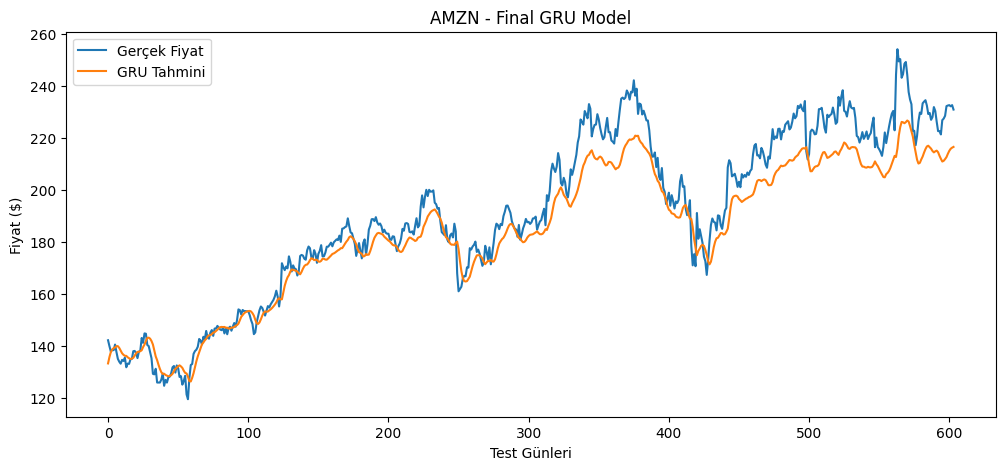

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(actual_final, label="Gerçek Fiyat")
plt.plot(predicted_final, label="GRU Tahmini")

plt.title("AMZN - Final GRU Model")
plt.xlabel("Test Günleri")
plt.ylabel("Fiyat ($)")
plt.legend()

plt.savefig(
    "../results/final_gru_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()